In [2]:
import sys
import os
# sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

In [3]:
model_names = ["llava-v1.6-vicuna-7b-hf", "Qwen2.5-VL-7B-Instruct", "InternVL2-8B"]

In [ ]:
for i in range(len(model_names)):
    data_name = f"results/inference/okvqa/validation/{model_names[i]}_output.csv"
    data_df = pd.read_csv(data_name, index_col=0)
    print(data_df.head())

                                            question answer generated_outputs
0               What is in the motorcyclist's mouth?      D                 D
1  Which number birthday is probably being celebr...      D                 D
2             What best describes the pool of water?      C                 C
3  What is the white substance on top of the cupc...      D                 D
4  What type of device is sitting next to the lap...      B                 B
                                            question answer generated_outputs
0               What is in the motorcyclist's mouth?      D          stant\nD
1  Which number birthday is probably being celebr...      D          stant\nD
2             What best describes the pool of water?      C          stant\nC
3  What is the white substance on top of the cupc...      D          stant\nD
4  What type of device is sitting next to the lap...      B          stant\nB
                                            question answer gene

In [13]:
data_df.head()

,Unnamed: 0,question,answer,generated_outputs
0,0,What is in the motorcyclist's mouth?,D,(D) cigarette
1,1,Which number birthday is probably being celebr...,D,(D) thirty
2,2,What best describes the pool of water?,C,(B) fresh
3,3,What is the white substance on top of the cupc...,D,(D) icing
4,4,What type of device is sitting next to the lap...,B,(B) mobile phone


In [1]:
from data_generator.inference_loader import load_infer_prob_data


/home/hice1/stekin6/.conda/envs/llamas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data = load_infer_prob_data(model_names, "okvqa", "validation")

In [6]:
data.shape

(1145, 13)

In [7]:
label = data[:, -1]

In [8]:
label

array([3., 3., 2., ..., 3., 3., 0.])

In [24]:
model_probs = np.split(data[:, :-1], 3, axis=1)
model_preds = []
for i in range(len(model_names)):
    print(np.mean(model_probs[i].argmax(1) == label))
    model_preds.append(model_probs[i].argmax(1))

0.8262008733624454
0.8724890829694323
0.8532751091703057


In [123]:
model_preds = np.array(model_preds)

In [134]:
from ens_pruning.ens_methods import voting

voting(model_preds.T, "plurality")

array([3, 3, 2, ..., 3, 3, 0])

In [124]:
model_preds.shape

(3, 1145)

In [125]:
model_preds

array([[3, 3, 2, ..., 3, 3, 0],
       [3, 3, 2, ..., 0, 2, 0],
       [3, 3, 1, ..., 3, 3, 0]])

In [22]:
from models.multi_encoder import MultiEncoderSharedAutoencoder


In [126]:
classifications = (model_preds == label).sum(axis=0)

In [127]:
classifications

array([3, 3, 2, ..., 2, 2, 3])

In [32]:
from train_multi_encoder import  EmbeddingLoader, collate_fn
from torch.utils.data import Dataset, DataLoader


dataset_name = "okvqa"
val_dataset = EmbeddingLoader(dataset_name, model_names, split_type="validation")
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


loading embeddings


/storage/ice1/1/5/stekin6/rl-vqa/train_multi_encoder.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.embeddings.append(torch.load(save_path))


embeddings are loaded


In [ ]:
model_save_path = os.path.join("results", "latent_map_models", f"latent_map_model.pth")
dims = [1024, 3584, 1024]
enc_dec = MultiEncoderSharedAutoencoder(dims, latent_dim=512)
state_dict = torch.load(model_save_path, weights_only=True)
enc_dec.load_state_dict(state_dict)

<All keys matched successfully>

In [85]:
def wcss(vectors):
    """
    vectors: list or tensor of shape (n, d)
    returns: WCSS and mean distance
    """
    X = torch.stack(vectors)  # shape (n, d)
    centroid = X.mean(dim=0, keepdim=True)
    diffs = X - centroid
    wcss_val = (diffs ** 2).sum(dim=(0, -1))         # total sum of squares
    # mean_dist = torch.sqrt((diffs ** 2).sum(dim=1)).mean().item()  # mean Euclidean distance
    # return wcss_val, mean_dist
    return wcss_val


In [86]:
enc_dec.to("cuda")
total_diff = []
for batch in val_dataloader:
    batch = [k.to("cuda").float() for k in batch]
    with torch.no_grad():
        latents, recons = enc_dec(batch)
    total_diff.append(wcss(latents))

In [95]:
total_diff_arr = torch.cat(total_diff).cpu().numpy()

In [75]:
(diffs ** 2).sum(dim=(0, -1))

tensor([0.0010, 0.0005, 0.0005, 0.0013, 0.0009, 0.0005, 0.0005, 0.0006, 0.0006,
        0.0004, 0.0006, 0.0004, 0.0006, 0.0003, 0.0004, 0.0006, 0.0028, 0.0004,
        0.0007, 0.0008, 0.0004, 0.0003, 0.0007, 0.0006, 0.0005, 0.0006, 0.0011,
        0.0005, 0.0005, 0.0005, 0.0003, 0.0005], device='cuda:0')

In [91]:
total_diff_arr[:10]

tensor([0.0010, 0.0005, 0.0005, 0.0013, 0.0009, 0.0005, 0.0005, 0.0006, 0.0006,
        0.0004], device='cuda:0')

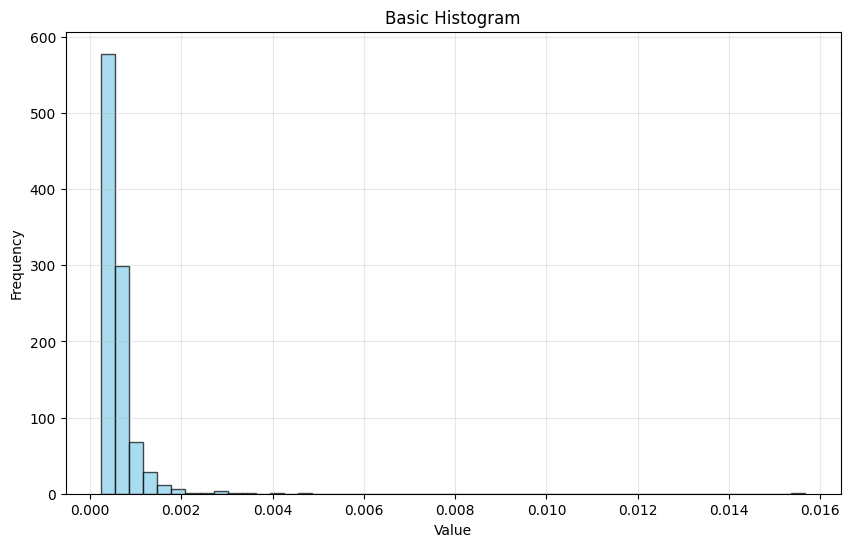

array([3, 3, 2, ..., 3, 3, 1])

In [ ]:

plt.figure(figsize=(10, 6))
plt.hist(total_diff_arr, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Basic Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()



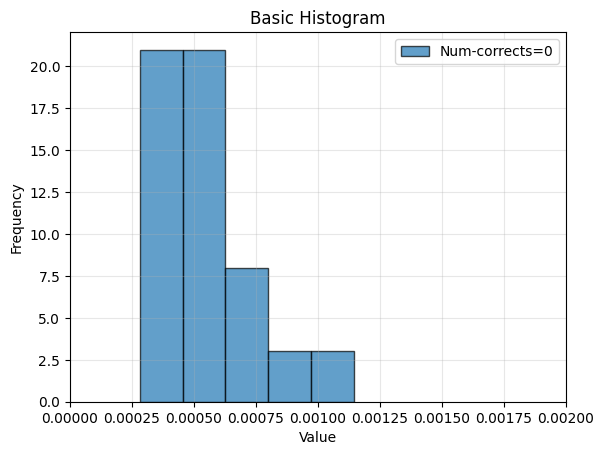

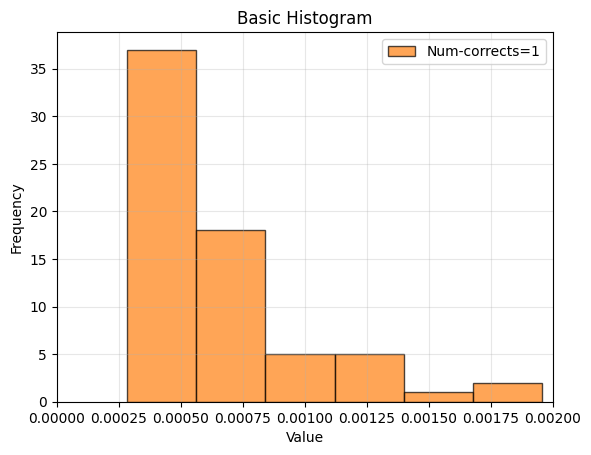

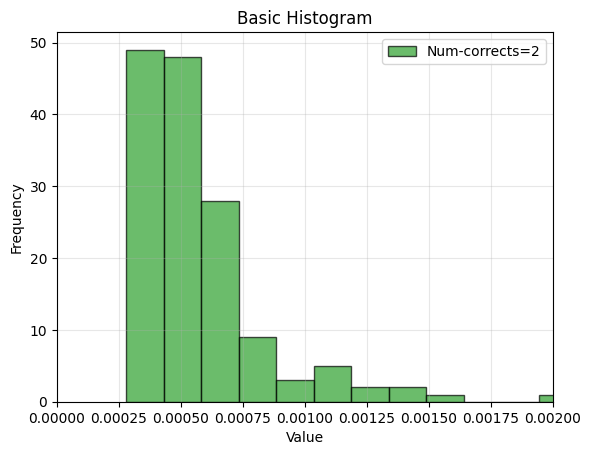

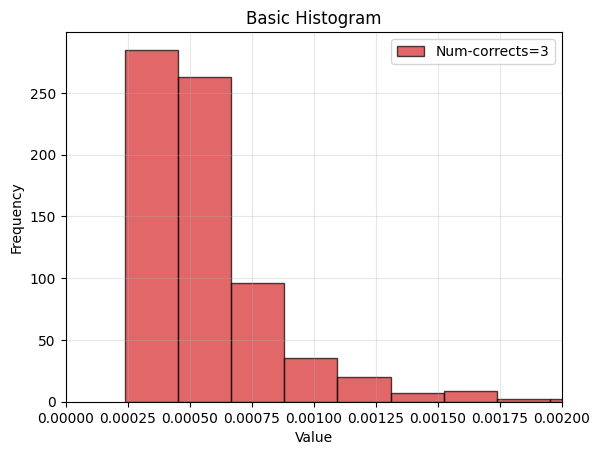

In [135]:
total_idx = classifications[:1001]

for i in range(4):
    idx = total_idx == i
    plt.figure()
    plt.hist(total_diff_arr[idx], bins=sum(idx)//10, alpha=0.7, color=f"C{i}", edgecolor='black', label=f"Num-corrects={i}")
    plt.xlim(0, 0.002)
    plt.title('Basic Histogram')
    plt.legend()
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()


In [103]:
total_idx == 3

array([ True,  True, False, ...,  True,  True, False])